# Bayesian Calibration of the Intelligent Driver Model (IDM)


In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import logging
for logger_name in ["pymc", "pymc.sampling", "pymc.stats.convergence"]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from src.data_loader import load_ngsim_csv
from src.classical_calibration import calibrate_lsq, calibrate_lsq_multi_start
from src.bayesian_calibration import (
    build_single_vehicle_model, build_hierarchical_model, sample_model)
from src.idm_simulator import observed_acceleration
from src.utils import plot_trajectories

RANDOM_SEED = 42
DT = 0.1


## 1. Load real NGSIM vehicle trajectory data

In [2]:
df_locs = pd.read_csv("../data/raw/NGSIM_Data_2026.csv", usecols=["Location"])
print(df_locs["Location"].unique())


<StringArray>
['us-101', 'i-80', nan]
Length: 3, dtype: str


In [3]:
df_check = pd.read_csv("../data/raw/NGSIM_Data_2026.csv",
                        usecols=["Vehicle_ID","Preceding","Frame_ID","Local_Y","v_Vel"],
                        nrows=1000)
print(df_check.dtypes)
print(df_check.head())


Vehicle_ID      int64
Frame_ID        int64
Local_Y           str
v_Vel         float64
Preceding         str
dtype: object
   Vehicle_ID  Frame_ID    Local_Y  v_Vel Preceding
0         809      2419  2,195.462  53.50         0
1        1432      7510  2,226.865  44.25         0
2         809      2418  2,190.111  53.50         0
3        1432      7509   2,222.44  44.25         0
4         809      2417  2,184.762  53.50         0


In [4]:
pairs = load_ngsim_csv(
    "../data/raw/NGSIM_Data_2026.csv",
    location_col="Location",
    location_value=["us-101", "i-80"],
    max_pairs=400,
)
print(f"Found {len(pairs)} leader-follower pairs")


Found 400 leader-follower pairs


## 2. Select free-flow and congested vehicle pairs

In [5]:
candidates = []
for veh_id, lead_id, df in pairs:
    if len(df) < 50:
        continue
    gap = df["leader_pos"] - df["follower_pos"]
    mean_gap = gap.mean()
    min_gap = gap.min()

    if min_gap < 0:
        continue

    candidates.append({
        "veh_id": veh_id, "lead_id": lead_id, "df": df,
        "n_frames": len(df),
        "mean_gap": mean_gap,
        "min_gap": min_gap,
        "mean_speed": df["follower_speed_obs"].mean(),
        "max_speed": df["follower_speed_obs"].max(),
    })

print(f"{len(candidates)} clean candidates (after dropping negative-gap pairs)\n")


by_speed = sorted(candidates, key=lambda c: -c["mean_speed"])
print("=== Fastest pairs (free-flow candidates) ===")
for i, c in enumerate(by_speed[:10]):
    print(f"{i} | veh:{c['veh_id']} lead:{c['lead_id']} | frames:{c['n_frames']} "
          f"| mean_gap:{c['mean_gap']:.1f} | mean_speed:{c['mean_speed']:.1f} "
          f"| max_speed:{c['max_speed']:.1f}")

print()


congested_pool = [c for c in candidates if c["n_frames"] >= 200]
by_gap = sorted(congested_pool, key=lambda c: c["mean_gap"])
print("=== Smallest-gap pairs with 200+ frames (congested candidates) ===")
for i, c in enumerate(by_gap[:10]):
    print(f"{i} | veh:{c['veh_id']} lead:{c['lead_id']} | frames:{c['n_frames']} "
          f"| mean_gap:{c['mean_gap']:.1f} | mean_speed:{c['mean_speed']:.1f}")


4 clean candidates (after dropping negative-gap pairs)

=== Fastest pairs (free-flow candidates) ===
0 | veh:253.0 lead:3101.0 | frames:299 | mean_gap:86.4 | mean_speed:15.2 | max_speed:27.0
1 | veh:406.0 lead:2861.0 | frames:425 | mean_gap:58.8 | mean_speed:8.6 | max_speed:16.1
2 | veh:413.0 lead:2862.0 | frames:482 | mean_gap:43.5 | mean_speed:8.5 | max_speed:13.5
3 | veh:419.0 lead:2863.0 | frames:521 | mean_gap:13.5 | mean_speed:8.0 | max_speed:12.2

=== Smallest-gap pairs with 200+ frames (congested candidates) ===
0 | veh:419.0 lead:2863.0 | frames:521 | mean_gap:13.5 | mean_speed:8.0
1 | veh:413.0 lead:2862.0 | frames:482 | mean_gap:43.5 | mean_speed:8.5
2 | veh:406.0 lead:2861.0 | frames:425 | mean_gap:58.8 | mean_speed:8.6
3 | veh:253.0 lead:3101.0 | frames:299 | mean_gap:86.4 | mean_speed:15.2


In [6]:
free_pick = next(c for c in candidates if c["veh_id"] == 253.0 and c["lead_id"] == 3101.0)
cong_pick = next(c for c in candidates if c["veh_id"] == 419.0 and c["lead_id"] == 2863.0)

df_free = free_pick["df"]
df_cong = cong_pick["df"]

print("Free-flow pair:", len(df_free), "frames")
print("Congested pair:", len(df_cong), "frames")


Free-flow pair: 299 frames
Congested pair: 521 frames


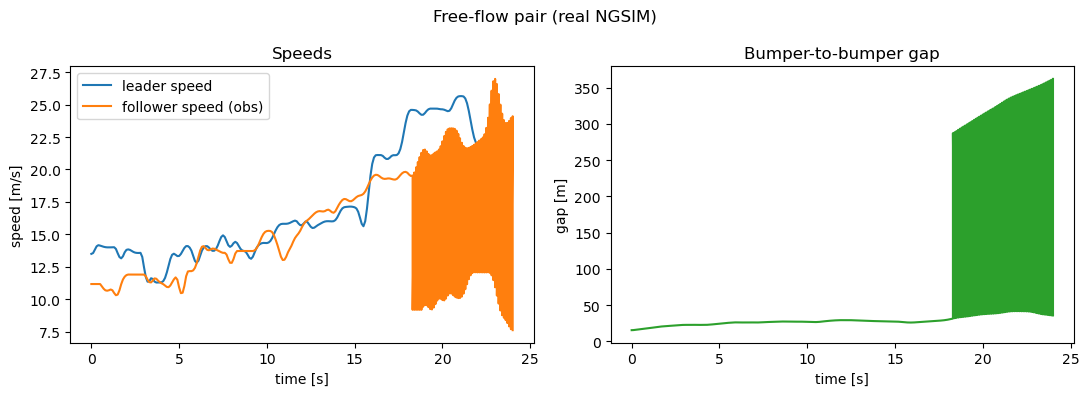

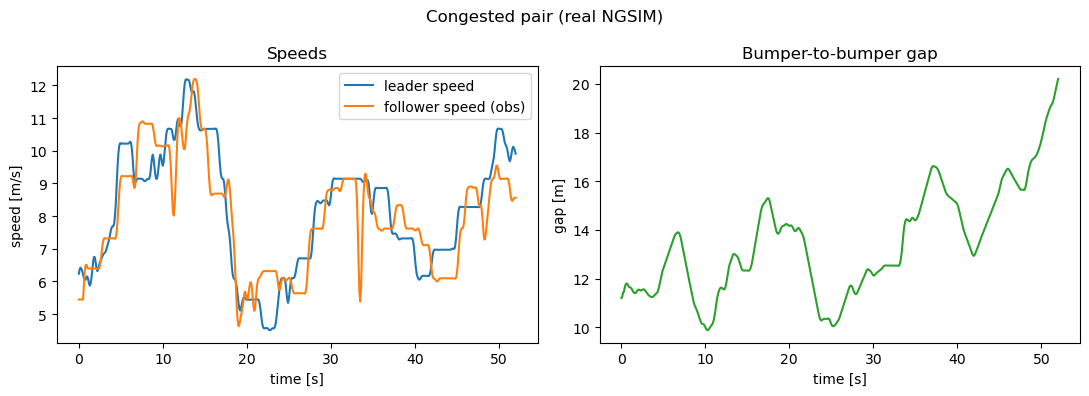

In [7]:
_ = plot_trajectories(df_free, title="Free-flow pair (real NGSIM)")
plt.show()
_ = plot_trajectories(df_cong, title="Congested pair (real NGSIM)")
plt.show()


## 3. Classical least-squares baseline

In [8]:
fit_free = calibrate_lsq(df_free, dt=DT)
fit_cong = calibrate_lsq(df_cong, dt=DT)
print(fit_free)
print(fit_cong)


{'v0': np.float64(20.510469078240078), 'T': np.float64(0.3000000003045185), 'a_max': np.float64(0.30000000000000415), 'b': np.float64(2.3798464906339545), 's0': np.float64(0.10000000037247454), 'rmse': np.float64(10.148933599067332), 'success': True, 'raw_result':      message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 2.736e-01  2.736e-01 ... -7.187e-01  1.653e+02]
           x: [ 2.051e+01  3.000e-01  3.000e-01  2.380e+00  1.000e-01]
        cost: 15398.62755314253
         jac: [[ 5.137e-03  0.000e+00 ...  0.000e+00 -2.533e-04]
               [ 5.137e-03  0.000e+00 ...  0.000e+00 -2.500e-04]
               ...
               [ 1.116e-01 -6.863e-01 ...  3.103e-01 -2.847e-02]
               [ 1.107e-03  0.000e+00 ...  0.000e+00  0.000e+00]]
        grad: [-5.321e-06  6.454e+00  1.461e+02  8.994e-06  3.970e-01]
  optimality: 0.00010369594430480346
 active_mask: [ 0 -1 -1  0 -1]
        nfev: 8
        njev: 8}
{'v0': np.float64(39.922

### Bounds check


In [9]:
wider_bounds = (
    [5.0, 0.1, 0.1, 0.1, 0.05],   # lower
    [45.0, 6.0, 6.0, 8.0, 12.0],  # upper
)

fit_free2 = calibrate_lsq(df_free, dt=DT, bounds=wider_bounds)
fit_cong2 = calibrate_lsq(df_cong, dt=DT, bounds=wider_bounds)

print("FREE FLOW (wider bounds):")
print({k: fit_free2[k] for k in ['v0','T','a_max','b','s0','rmse']})
print("\nCONGESTED (wider bounds):")
print({k: fit_cong2[k] for k in ['v0','T','a_max','b','s0','rmse']})


FREE FLOW (wider bounds):
{'v0': np.float64(21.256119448255546), 'T': np.float64(0.10000002634972589), 'a_max': np.float64(0.10000000006632803), 'b': np.float64(1.6029730180219992), 's0': np.float64(0.05000001524659905), 'rmse': np.float64(10.140010377484451)}

CONGESTED (wider bounds):
{'v0': np.float64(44.99999999999756), 'T': np.float64(0.2880106821292807), 'a_max': np.float64(0.30614845146222797), 'b': np.float64(5.757558597045149), 's0': np.float64(8.928178449736821), 'rmse': np.float64(1.8553996352101487)}


### Robustness check: multiple random restarts

In [10]:
fits_free, _ = calibrate_lsq_multi_start(df_free, dt=DT, n_starts=8, bounds=wider_bounds, seed=1)
print("Free-flow: s0, T, a_max across 8 restarts")
for f in fits_free:
    print(f"  s0={f['s0']:.3f}  T={f['T']:.3f}  a_max={f['a_max']:.3f}  rmse={f['rmse']:.3f}")

fits_cong, _ = calibrate_lsq_multi_start(df_cong, dt=DT, bounds=wider_bounds, seed=1)
print("\nCongested: v0 across 8 restarts")
for f in fits_cong:
    print(f"  v0={f['v0']:.3f}  rmse={f['rmse']:.3f}")


Free-flow: s0, T, a_max across 8 restarts
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140

Congested: v0 across 8 restarts
  v0=45.000  rmse=1.855
  v0=44.601  rmse=1.856
  v0=44.776  rmse=1.856
  v0=40.562  rmse=1.855
  v0=44.744  rmse=1.855
  v0=44.999  rmse=1.855
  v0=44.397  rmse=1.855
  v0=45.000  rmse=1.855
  v0=44.893  rmse=1.855
  v0=44.995  rmse=1.855


## 4. Bayesian single-vehicle calibration


In [11]:
def prep(df):
    return dict(
        leader_pos=df["leader_pos"].values,
        leader_speed=df["leader_speed"].values,
        follower_pos=df["follower_pos"].values,
        follower_speed=df["follower_speed_obs"].values,
        obs_accel=observed_acceleration(df["follower_speed_obs"].values, DT),
    )

wider_priors = {
    "v0":    dict(mu=25.0, sigma=12.0, lower=5.0, upper=45.0),
    "T":     dict(mu=1.0, sigma=1.0, lower=0.1, upper=6.0),
    "a_max": dict(mu=1.0, sigma=1.0, lower=0.1, upper=6.0),
    "b":     dict(mu=2.5, sigma=1.5, lower=0.1, upper=8.0),
    "s0":    dict(mu=2.0, sigma=2.0, lower=0.05, upper=12.0),
}

model_free = build_single_vehicle_model(**prep(df_free), priors=wider_priors)
model_cong = build_single_vehicle_model(**prep(df_cong), priors=wider_priors)


In [12]:
idata_free = sample_model(model_free, draws=1000, tune=1000, target_accept=0.9, random_seed=RANDOM_SEED)
summary_df = az.summary(idata_free, var_names=["v0","T","a_max","b","s0"])
summary_df.to_csv("../outputs/results/free_flow_bayesian_calibration.csv", index = True)
print(summary_df)

Output()

        mean    sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
v0      28.3   7.4       17       41      2243      1569  1.00      0.16   
T       1.03  0.59     0.23        2      2314      1465  1.00     0.011   
a_max  0.424  0.29     0.12     0.98      2660      2068  1.00    0.0048   
b       2.92  1.22      1.1        5      3069      2296  1.00     0.022   
s0      2.51  1.55     0.36      5.2      2316      1470  1.00     0.028   

      mcse_sd  
v0      0.088  
T      0.0081  
a_max   0.005  
b       0.015  
s0       0.02  


In [13]:
idata_cong = sample_model(model_cong, draws=1000, tune=1000, target_accept=0.95, random_seed=RANDOM_SEED)
az.summary(idata_cong, var_names=["v0","T","a_max","b","s0"])
summary_df.to_csv("../outputs/results/cong_flow_bayesian_calibration.csv", index = True)
print(summary_df)

Output()

        mean    sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
v0      28.3   7.4       17       41      2243      1569  1.00      0.16   
T       1.03  0.59     0.23        2      2314      1465  1.00     0.011   
a_max  0.424  0.29     0.12     0.98      2660      2068  1.00    0.0048   
b       2.92  1.22      1.1        5      3069      2296  1.00     0.022   
s0      2.51  1.55     0.36      5.2      2316      1470  1.00     0.028   

      mcse_sd  
v0      0.088  
T      0.0081  
a_max   0.005  
b       0.015  
s0       0.02  


## 5. Free-flow vs. congested: posterior comparison


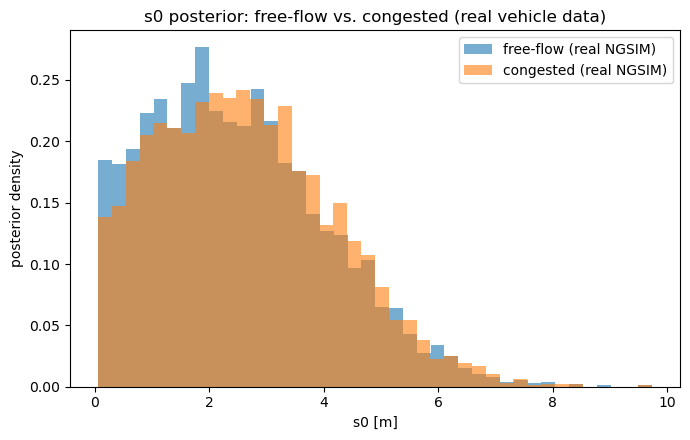

In [14]:
s0_free = idata_free.posterior["s0"].values.flatten()
s0_cong = idata_cong.posterior["s0"].values.flatten()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(s0_free, bins=40, alpha=0.6, density=True, label="free-flow (real NGSIM)")
ax.hist(s0_cong, bins=40, alpha=0.6, density=True, label="congested (real NGSIM)")
ax.set_xlabel("s0 [m]")
ax.set_ylabel("posterior density")
ax.set_title("s0 posterior: free-flow vs. congested (real vehicle data)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/s0_real_data_comparison.png", dpi=150)
plt.show()


## 6. Per-vehicle sweep and hierarchical model (real data)


In [15]:
real_multi_fits = []
for c in candidates:
    fit = calibrate_lsq(c["df"], dt=DT, bounds=wider_bounds)
    real_multi_fits.append({**c, **fit})
    print(f"veh:{c['veh_id']} lead:{c['lead_id']} | mean_gap:{c['mean_gap']:.1f} "
          f"| s0={fit['s0']:.2f} T={fit['T']:.2f} v0={fit['v0']:.1f} rmse={fit['rmse']:.2f}")


veh:253.0 lead:3101.0 | mean_gap:86.4 | s0=0.05 T=0.10 v0=21.3 rmse=10.14
veh:406.0 lead:2861.0 | mean_gap:58.8 | s0=12.00 T=6.00 v0=45.0 rmse=2.80
veh:413.0 lead:2862.0 | mean_gap:43.5 | s0=12.00 T=3.18 v0=45.0 rmse=3.01
veh:419.0 lead:2863.0 | mean_gap:13.5 | s0=8.93 T=0.29 v0=45.0 rmse=1.86


In [16]:
vehicle_data_list = []
for c in candidates:
    d = c["df"]
    vehicle_data_list.append(dict(
        leader_pos=d["leader_pos"].values,
        leader_speed=d["leader_speed"].values,
        follower_pos=d["follower_pos"].values,
        follower_speed=d["follower_speed_obs"].values,
        obs_accel=observed_acceleration(d["follower_speed_obs"].values, DT),
    ))

hier_model = build_hierarchical_model(vehicle_data_list)

idata_hier = sample_model(hier_model, draws=800, tune=2000, chains=4,
                           target_accept=0.99, random_seed=RANDOM_SEED)

az.summary(idata_hier, var_names=[
    "mu_log_v0","mu_log_T","mu_log_amax","mu_log_b","mu_log_s0"])


Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_log_v0,3.264,0.255,2.9,3.7,3084,2001,1.00,0.0046,0.0032
mu_log_T,0.21,0.255,-0.2,0.62,2204,2375,1.00,0.0054,0.004
mu_log_amax,-0.56,0.3,-1,-0.056,1091,1463,1.01,0.0091,0.0063
mu_log_b,0.76,0.286,0.31,1.2,3482,2435,1.00,0.0049,0.0035
mu_log_s0,0.67,0.49,-0.13,1.4,2926,2195,1.00,0.009,0.0064


## 7. Save results

In [17]:
summary_table = pd.DataFrame([
    {"regime": "free-flow", "param": "s0", "mean": s0_free.mean(), "sd": s0_free.std()},
    {"regime": "congested", "param": "s0", "mean": s0_cong.mean(), "sd": s0_cong.std()},
])
summary_table.to_csv("../outputs/results/real_data_s0_comparison.csv", index=False)
print(summary_table)


      regime param      mean        sd
0  free-flow    s0  2.510210  1.547751
1  congested    s0  2.644128  1.536285


## 8. Simulation

### Static plots (position, speed, gap over time)

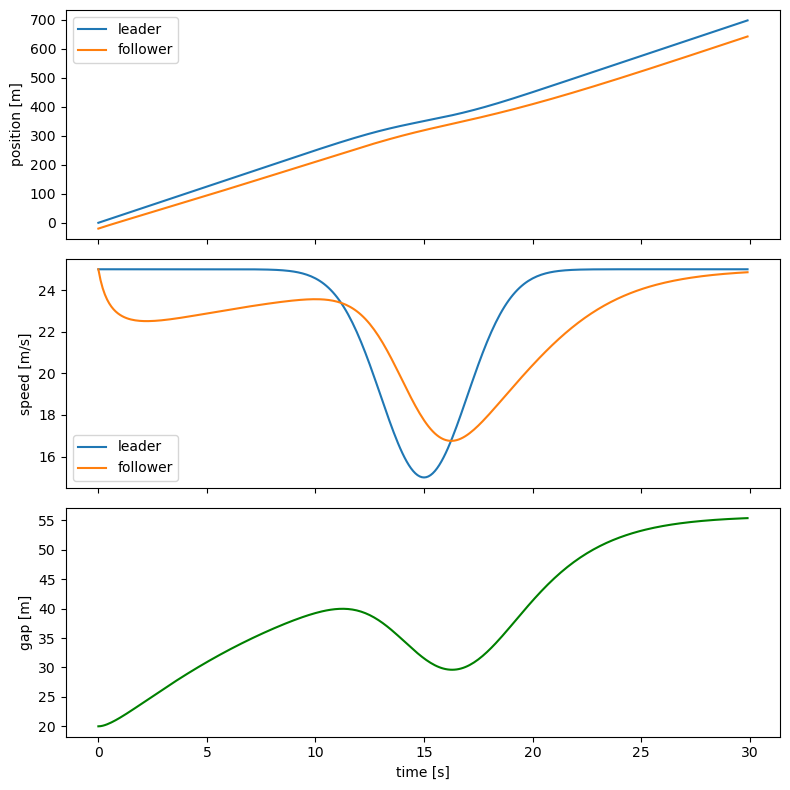

In [18]:
import sys
sys.path.insert(0, "..")   # adjust if needed, so it finds src/
import numpy as np
import matplotlib.pyplot as plt
from src.idm_simulator import simulate_follower

# Build a simple leader trajectory: cruises at 25 m/s, then brakes, then speeds up
dt = 0.1
n_steps = 300
t = np.arange(n_steps) * dt

leader_speed = 25 - 10 * np.exp(-((t - 15)**2) / 8)   # dip in speed around t=15s
leader_pos = np.concatenate([[0], np.cumsum(leader_speed[:-1] * dt)])

# Simulate a follower starting 20m behind, same initial speed
result = simulate_follower(
    leader_pos, leader_speed, dt,
    v0=30.0, T=1.5, a_max=1.5, b=2.0, s0=2.5,
    init_pos=leader_pos[0] - 20.0, init_speed=leader_speed[0],
)

follower_pos = result["position"]
follower_speed = result["speed"]
gap = leader_pos - follower_pos

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axes[0].plot(t, leader_pos, label="leader")
axes[0].plot(t, follower_pos, label="follower")
axes[0].set_ylabel("position [m]")
axes[0].legend()

axes[1].plot(t, leader_speed, label="leader")
axes[1].plot(t, follower_speed, label="follower")
axes[1].set_ylabel("speed [m/s]")
axes[1].legend()

axes[2].plot(t, gap, color="green")
axes[2].set_ylabel("gap [m]")
axes[2].set_xlabel("time [s]")

plt.tight_layout()
plt.show()

### Animated visual (two dots moving on a road)

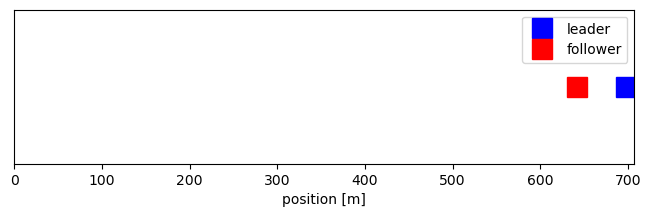

In [19]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 2))
ax.set_xlim(0, max(leader_pos.max(), follower_pos.max()) + 10)
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_xlabel("position [m]")

leader_dot, = ax.plot([], [], 'bs', markersize=15, label="leader")
follower_dot, = ax.plot([], [], 'rs', markersize=15, label="follower")
ax.legend(loc="upper right")

def update(frame):
    leader_dot.set_data([leader_pos[frame]], [0])
    follower_dot.set_data([follower_pos[frame]], [0])
    return leader_dot, follower_dot

ani = animation.FuncAnimation(fig, update, frames=n_steps, interval=50, blit=True)
HTML(ani.to_jshtml())   # renders inline in Jupyter


In [20]:
ani.save("../outputs/figures/idm_simulation.gif", writer="pillow", fps=15)